# 14 — Weekly Forecast Analysis
## SunnyBest Retail Forecasting System

> **Purpose:** Read, explore and visualise the weekly unit forecasts generated by the model.
> Run this notebook after `generate_weekly_forecast.py` to understand what the model is predicting.
> Forecast history starts from **Week 1 (commencing May 4, 2026)**.

| Section | What you see |
|---------|-------------|
| 1 | What weeks and models are in the forecast file |
| 2 | Forecast summary — total units per store |
| 3 | Forecast by category |
| 4 | Top 10 highest and lowest predicted products |
| 5 | Store × product heatmap |

---
## 0. Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import create_engine
from urllib.parse import quote_plus

plt.rcParams["figure.figsize"]    = (14, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
PALETTE = ["#4C72B0","#C44E52","#55A868","#DD8452","#8172B2","#64B5CD","#CCB974"]

FORECAST_PATH = "../data/outputs/weekly_forecasts.csv"

# DB connection — to enrich with product/store names
host     = "aws-1-eu-central-1.pooler.supabase.com"
port     = 5432
database = "postgres"
user     = "postgres.ogkdfmkybqtrsglcizzt"
password = quote_plus(os.getenv("SUPABASE_DB_PASSWORD", "Bonabosssfs01"))

engine = create_engine(
    f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}",
    pool_pre_ping=True, pool_recycle=300
)

print("Setup complete")

Setup complete


---
## 1. Load Forecasts & Enrich with Names

In [2]:
# ── Step 1: Load the forecast CSV ─────────────────────────────────────────────
# This file is generated by generate_weekly_forecast.py
# It contains predicted units for every store × product combination per week
df = pd.read_csv(FORECAST_PATH)
df["week_start"]      = pd.to_datetime(df["week_start"])       # convert to datetime
df["store_id"]        = df["store_id"].astype(str)             # keep as string for merging
df["product_id"]      = pd.to_numeric(df["product_id"], errors="coerce").astype(int)
df["predicted_units"] = pd.to_numeric(df["predicted_units"], errors="coerce")

# ── Step 2: Load dimension tables from Supabase ────────────────────────────────
# The forecast file only has IDs (store_id, product_id)
# We pull store names, product names, categories and prices from the DB
# so we can display readable labels instead of raw numbers
stores   = pd.read_sql("SELECT store_id::text, store_name, store_size, city, region FROM core.dim_stores", engine)
products = pd.read_sql("SELECT product_id, product_name, category, regular_price FROM core.dim_products", engine)
products["product_id"] = products["product_id"].astype(int)

# ── Step 3: Enrich the forecast with store and product names ───────────────────
df = df.merge(stores,   on="store_id",   how="left")
df = df.merge(products, on="product_id", how="left")

# ── Step 4: Filter to our forecast window (Week 1 of May onwards) ─────────────
# May 4 is Week 1 — everything from that date onwards is included
# This shows ALL forecast weeks, not just the latest one
FORECAST_START = "2026-05-04"
fc = df[df["week_start"] >= FORECAST_START].copy()
latest_week = fc["week_start"].max()  # most recent forecast week

# ── Step 5: Add friendly week labels ──────────────────────────────────────────
# Each forecast date gets a readable label e.g. "Week 1 (May 4)"
# ADD A NEW LINE HERE every time you generate a new forecast week
week_labels = {
    pd.Timestamp("2026-05-04"): "Week 1 (May 4)",
    pd.Timestamp("2026-05-11"): "Week 2 (May 11)",
    pd.Timestamp("2026-05-18"): "Week 3 (May 18)",
    pd.Timestamp("2026-05-25"): "Week 4 (May 25)",
}
fc["week_label"] = fc["week_start"].map(week_labels).fillna(fc["week_start"].dt.strftime("Week of %b %d"))

# ── Step 6: Print a summary of all forecast weeks loaded ──────────────────────
print(f"Forecast start : {FORECAST_START}")
print(f"Weeks loaded   : {fc['week_start'].nunique()} weeks\n")
for w, label in sorted(week_labels.items()):
    wk = fc[fc["week_start"] == w]
    if not wk.empty:
        print(f"  {label}  |  model: {wk['model_version'].iloc[0]}  |  {wk['predicted_units'].sum():,.0f} units predicted")

print(f"\nLatest week    : {latest_week.date()}")
print(f"Total rows     : {len(fc):,}  ({fc['week_start'].nunique()} weeks × {fc['store_id'].nunique()} stores × {fc['product_id'].nunique()} products)")
print()

# Preview — shows all weeks combined, first 15 rows
display(fc[["week_label", "store_name", "product_name", "category", "predicted_units", "regular_price"]].head(15))

Forecast start : 2026-05-04
Weeks loaded   : 4 weeks

  Week 1 (May 4)  |  model: weekly_model_v3_calendar  |  12,138 units predicted
  Week 2 (May 11)  |  model: weekly_model_v3_calendar_2026_05  |  12,436 units predicted
  Week 3 (May 18)  |  model: weekly_model_v3_calendar_2026_05  |  12,325 units predicted
  Week 4 (May 25)  |  model: weekly_model_v3_calendar_2026_05  |  12,335 units predicted

Latest week    : 2026-05-25
Total rows     : 3,360  (4 weeks × 7 stores × 120 products)



,week_label,store_name,product_name,category,predicted_units,regular_price
0,Week 1 (May 4),SunnyBest Benin Main,LG Televisions Model-120,Televisions,6.39,163694
1,Week 1 (May 4),SunnyBest Benin Main,Tecno Mobile Model-199,Mobile Phones,16.37,208266
2,Week 1 (May 4),SunnyBest Benin Main,Tecno Mobile Model-905,Mobile Phones,14.44,107221
3,Week 1 (May 4),SunnyBest Benin Main,Infinix Mobile Model-847,Mobile Phones,18.14,224779
4,Week 1 (May 4),SunnyBest Benin Main,Tecno Mobile Model-289,Mobile Phones,7.65,196730
5,Week 1 (May 4),SunnyBest Benin Main,Tecno Mobile Model-230,Mobile Phones,10.71,107435
6,Week 1 (May 4),SunnyBest Benin Main,Generic Accessories Model-415,Accessories,23.49,16502
7,Week 1 (May 4),SunnyBest Benin Main,Hisense Air Model-439,Air Conditioners,5.27,297624
8,Week 1 (May 4),SunnyBest Benin Main,Acer Laptops Model-134,Laptops & Computers,8.91,168555
9,Week 1 (May 4),SunnyBest Benin Main,Anker Accessories Model-489,Accessories,65.73,5943


In [3]:
display(fc[["week_label","store_name","product_name","category","predicted_units","regular_price"]].tail(15))

,week_label,store_name,product_name,category,predicted_units,regular_price
3345,Week 4 (May 25),SunnyBest Ogwa,Samsung Mobile Model-244,Mobile Phones,13.85,44835
3346,Week 4 (May 25),SunnyBest Ogwa,Asus Laptops Model-657,Laptops & Computers,2.34,439187
3347,Week 4 (May 25),SunnyBest Ogwa,Apple Mobile Model-549,Mobile Phones,6.72,96178
3348,Week 4 (May 25),SunnyBest Ogwa,Apple Mobile Model-900,Mobile Phones,6.73,96570
3349,Week 4 (May 25),SunnyBest Ogwa,ZTE Network Model-952,Network Devices,0.32,18415
3350,Week 4 (May 25),SunnyBest Ogwa,Binatone Small Model-560,Small Appliances,17.39,28309
3351,Week 4 (May 25),SunnyBest Ogwa,Samsung Mobile Model-922,Mobile Phones,16.29,145570
3352,Week 4 (May 25),SunnyBest Ogwa,Oraimo Accessories Model-122,Accessories,36.32,11860
3353,Week 4 (May 25),SunnyBest Ogwa,Huawei Network Model-184,Network Devices,9.93,14809
3354,Week 4 (May 25),SunnyBest Ogwa,Hisense Refrigerators Model-871,Refrigerators,0.00,255888


---
## 2. Forecast Summary by Store

> Which stores are expected to sell the most units this week?

,store_name,store_size,city,predicted_units,products
2,SunnyBest Benin Main,Large,Benin,11280.9,120
3,SunnyBest Ekpoma,Medium,Ekpoma,7632.2,120
1,SunnyBest Auchi,Medium,Auchi,7044.1,120
0,SunnyBest Agenebode,Small,Agenebode,6047.2,120
6,SunnyBest Ogwa,Small,Ogwa,6009.0,120
4,SunnyBest Igueben,Small,Igueben,5842.2,120
5,SunnyBest Irrua,Small,Irrua,5379.1,120


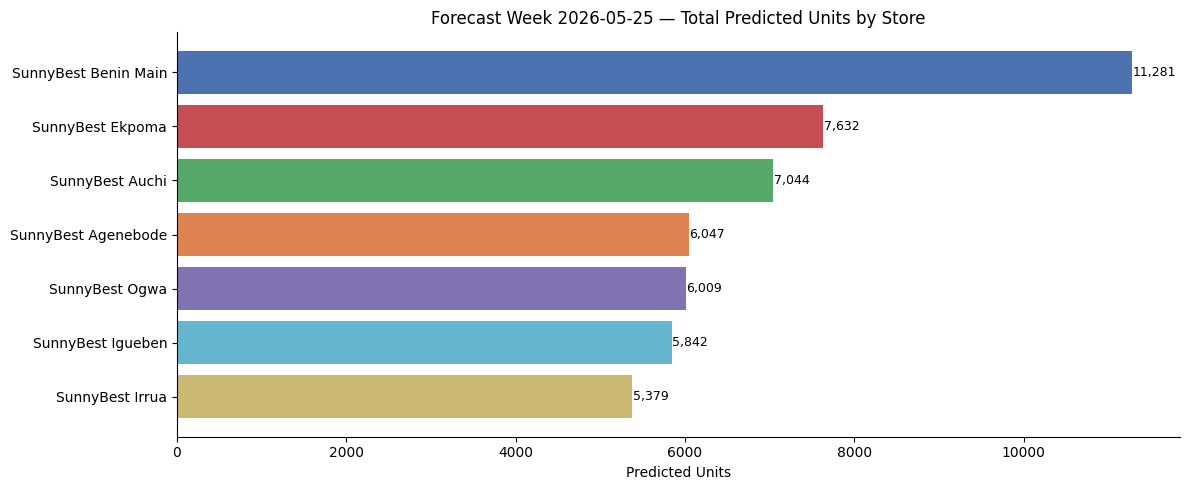

In [4]:
by_store = (fc.groupby(["store_name","store_size","city"])
              .agg(predicted_units=("predicted_units","sum"),
                   products       =("product_id","nunique"))
              .reset_index()
              .sort_values("predicted_units", ascending=False))

by_store["predicted_units"] = by_store["predicted_units"].round(1)
display(by_store)

fig, ax = plt.subplots(figsize=(12, 5))
colors = [PALETTE[i % len(PALETTE)] for i in range(len(by_store))]
ax.barh(by_store["store_name"][::-1], by_store["predicted_units"][::-1], color=colors[::-1])
ax.set_xlabel("Predicted Units")
ax.set_title(f"Forecast Week {latest_week.date()} — Total Predicted Units by Store")
for i, (_, row) in enumerate(by_store[::-1].iterrows()):
    ax.text(row["predicted_units"] + 5, i, f"{row['predicted_units']:,.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

---
## 3. Forecast by Category

> Which product categories drive the most volume this week?

,category,predicted_units,products,avg_price,predicted_revenue
7,Telecom Services,18903.4,5,5013.000000,9.476284e+07
0,Accessories,8395.4,10,12610.600000,1.058704e+08
3,Mobile Phones,7780.9,25,159590.680000,1.241758e+09
6,Small Appliances,7753.9,17,22091.764706,1.712967e+08
4,Network Devices,2786.8,14,38479.714286,1.072345e+08
2,Laptops & Computers,2193.8,19,269543.315789,5.913106e+08
8,Televisions,754.8,10,163227.700000,1.232092e+08
1,Air Conditioners,546.8,14,192599.428571,1.053076e+08
5,Refrigerators,119.1,6,236231.833333,2.814466e+07


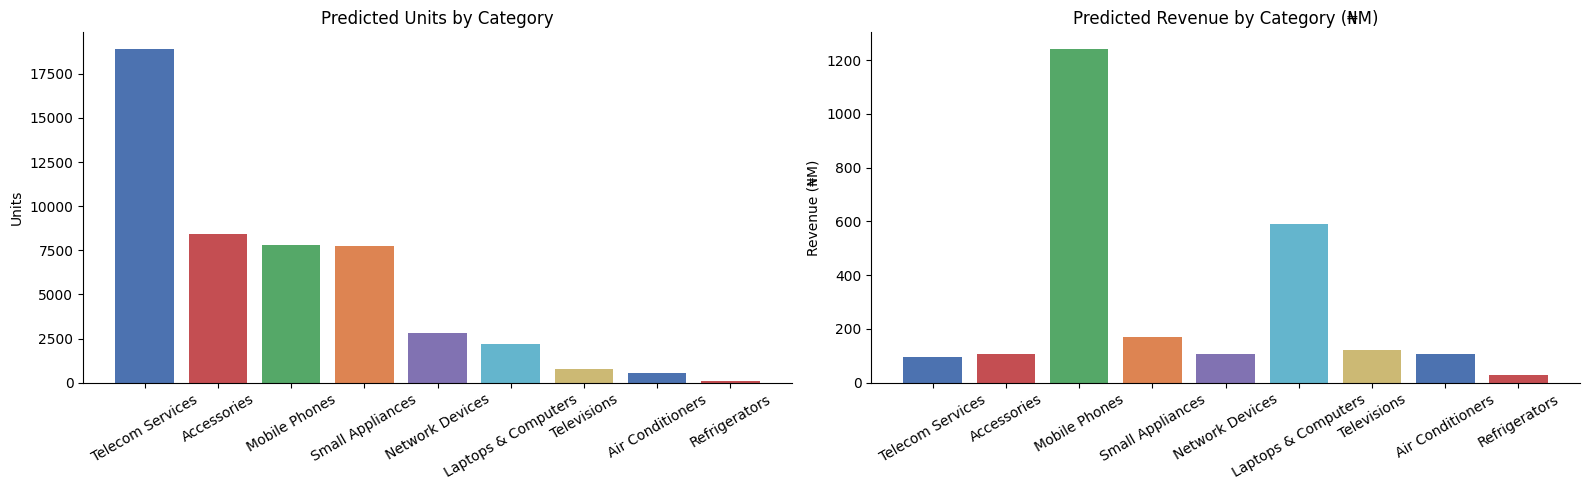

In [5]:
by_cat = (fc.groupby("category")
            .agg(predicted_units=("predicted_units","sum"),
                 products       =("product_id","nunique"),
                 avg_price      =("regular_price","mean"))
            .reset_index()
            .sort_values("predicted_units", ascending=False))

by_cat["predicted_revenue"] = (by_cat["predicted_units"] * by_cat["avg_price"]).round(0)
by_cat["predicted_units"]   = by_cat["predicted_units"].round(1)
display(by_cat)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(by_cat["category"], by_cat["predicted_units"],
            color=PALETTE[:len(by_cat)])
axes[0].set_title("Predicted Units by Category")
axes[0].set_ylabel("Units")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(by_cat["category"], by_cat["predicted_revenue"] / 1e6,
            color=PALETTE[:len(by_cat)])
axes[1].set_title("Predicted Revenue by Category (₦M)")
axes[1].set_ylabel("Revenue (₦M)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

---
## 4. Top 10 Highest & Lowest Predicted Products

> Highest — fast movers to ensure are well stocked.  
> Lowest — slow movers to watch for dead stock.

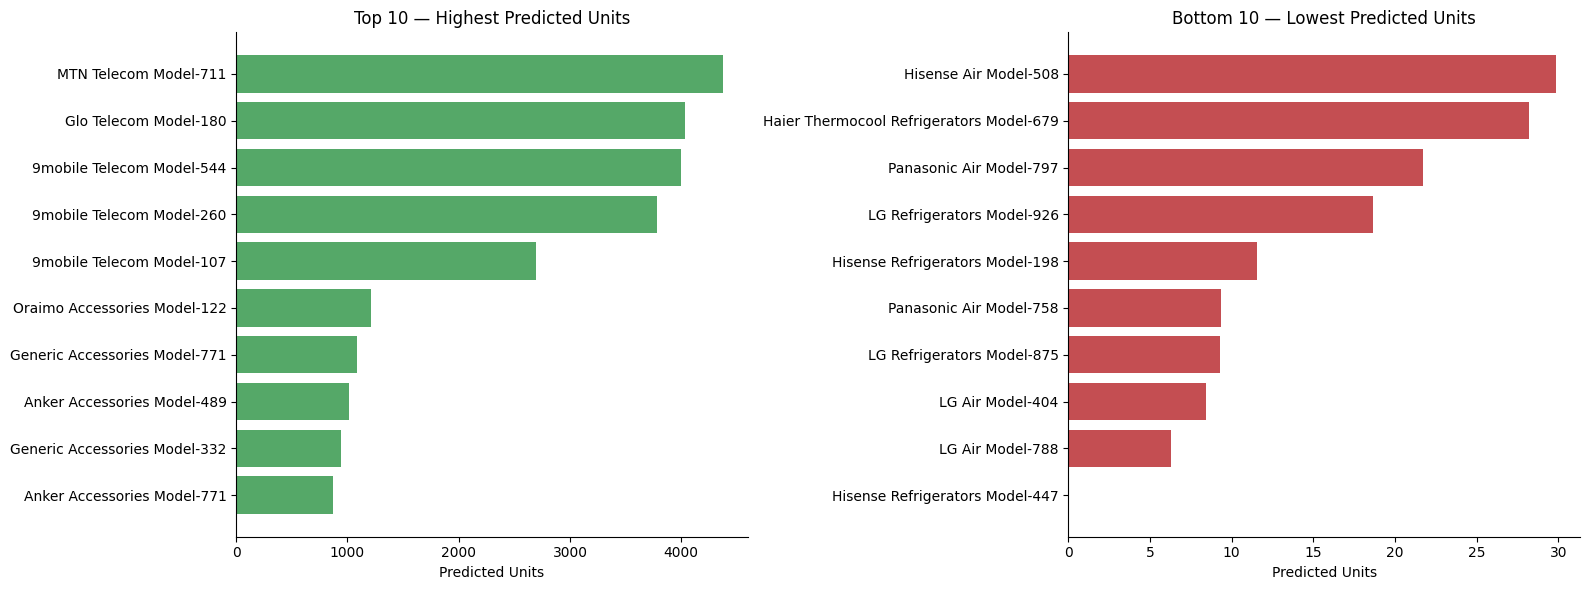

Top 10:


,product_name,category,regular_price,predicted_units
0,MTN Telecom Model-711,Telecom Services,7117,4379.85
1,Glo Telecom Model-180,Telecom Services,8054,4038.51
2,9mobile Telecom Model-544,Telecom Services,3641,4002.70
3,9mobile Telecom Model-260,Telecom Services,690,3784.68
4,9mobile Telecom Model-107,Telecom Services,5563,2697.68
5,Oraimo Accessories Model-122,Accessories,11860,1216.04
6,Generic Accessories Model-771,Accessories,15949,1085.17
7,Anker Accessories Model-489,Accessories,5943,1012.39
8,Generic Accessories Model-332,Accessories,15843,940.19
9,Anker Accessories Model-771,Accessories,15428,869.47



Bottom 10:


,product_name,category,regular_price,predicted_units
0,Hisense Refrigerators Model-447,Refrigerators,264013,0.04
1,LG Air Model-788,Air Conditioners,108888,6.28
2,LG Air Model-404,Air Conditioners,112677,8.43
3,LG Refrigerators Model-875,Refrigerators,200627,9.26
4,Panasonic Air Model-758,Air Conditioners,293766,9.33
5,Hisense Refrigerators Model-198,Refrigerators,95486,11.54
6,LG Refrigerators Model-926,Refrigerators,319170,18.65
7,Panasonic Air Model-797,Air Conditioners,214862,21.72
8,Haier Thermocool Refrigerators Model-679,Refrigerators,282207,28.18
9,Hisense Air Model-508,Air Conditioners,156040,29.83


In [6]:
by_product = (fc.groupby(["product_id","product_name","category","regular_price"])
                .agg(predicted_units=("predicted_units","sum"))
                .reset_index()
                .sort_values("predicted_units", ascending=False))

top10    = by_product.head(10)
bottom10 = by_product.tail(10).sort_values("predicted_units")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top10["product_name"][::-1], top10["predicted_units"][::-1], color=PALETTE[2])
axes[0].set_title("Top 10 — Highest Predicted Units")
axes[0].set_xlabel("Predicted Units")

axes[1].barh(bottom10["product_name"], bottom10["predicted_units"], color=PALETTE[1])
axes[1].set_title("Bottom 10 — Lowest Predicted Units")
axes[1].set_xlabel("Predicted Units")

plt.tight_layout()
plt.show()

print("Top 10:")
display(top10[["product_name","category","regular_price","predicted_units"]].reset_index(drop=True))
print("\nBottom 10:")
display(bottom10[["product_name","category","regular_price","predicted_units"]].reset_index(drop=True))

---
## 5. Store × Category Heatmap

> Which store-category combinations drive the most volume?  
> Useful for deciding where to focus replenishment effort this week.

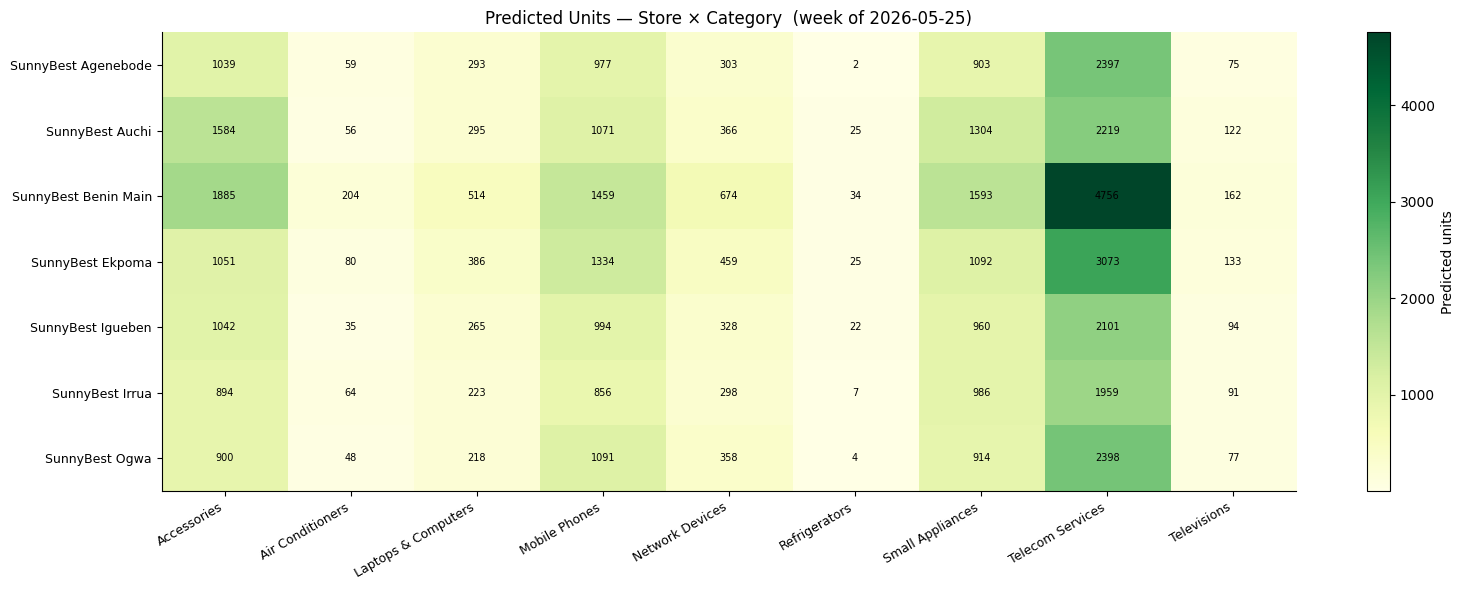

In [7]:
pivot = (fc.groupby(["store_name","category"])["predicted_units"]
           .sum()
           .round(1)
           .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(pivot.values, cmap="YlGn", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_title(f"Predicted Units — Store × Category  (week of {latest_week.date()})")
plt.colorbar(im, ax=ax, label="Predicted units")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i,j]:.0f}",
                ha="center", va="center", fontsize=7, color="black")

plt.tight_layout()
plt.show()

---
## 6. All Forecast Weeks (History)

> If you've run the forecast script multiple times, this shows all weeks side by side.

,week_start,model_version,total_predicted,rows
0,2026-05-04,weekly_model_v3_calendar,12138.0,840
1,2026-05-11,weekly_model_v3_calendar_2026_05,12436.0,840
2,2026-05-18,weekly_model_v3_calendar_2026_05,12325.0,840
3,2026-05-25,weekly_model_v3_calendar_2026_05,12335.0,840


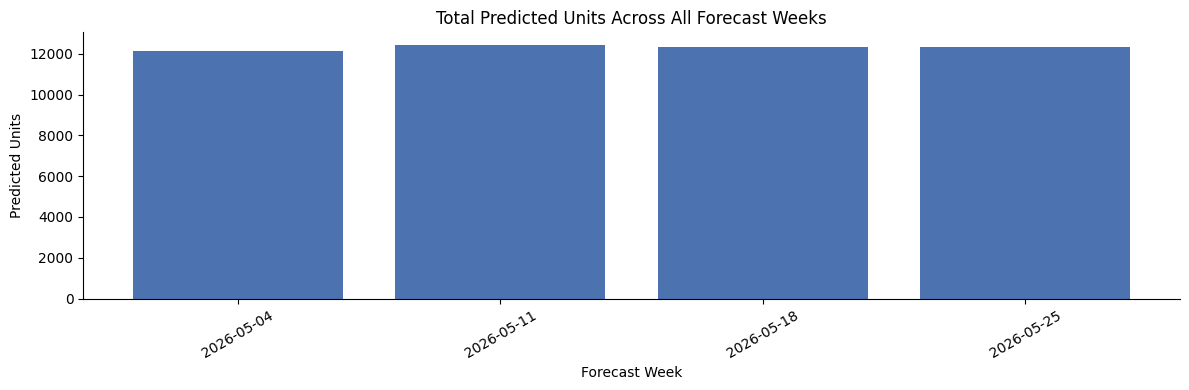

In [8]:
all_weeks = (df.groupby(["week_start","model_version"])
               .agg(total_predicted=("predicted_units","sum"),
                    rows=("product_id","count"))
               .reset_index())

all_weeks["total_predicted"] = all_weeks["total_predicted"].round(0)
display(all_weeks)

if len(all_weeks) > 1:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(all_weeks["week_start"].dt.strftime("%Y-%m-%d"),
           all_weeks["total_predicted"], color=PALETTE[0])
    ax.set_title("Total Predicted Units Across All Forecast Weeks")
    ax.set_ylabel("Predicted Units")
    ax.set_xlabel("Forecast Week")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("Only one forecast week so far — run the forecast script again next Saturday to build history.")

In [9]:
#df_forecast = pd.read_csv("../data/outputs/weekly_forecasts.csv")

In [10]:
# may11 = df_forecast[
#     (df_forecast["week_start"] == "2026-05-11") &
#     (df_forecast["model_version"] == "weekly_model_v3_calendar_2026_05")
# ]
# may11["week_start"] = pd.to_datetime(may11["week_start"])

In [11]:
# may11.head()

In [12]:
# from src.data.db_connection import run_query

# actuals = run_query("""
#     SELECT
#         DATE_TRUNC('week', date)::date  AS week_start,
#         store_id::text                  AS store_id,
#         product_id,
#         SUM(units_sold)                 AS units_sold
#     FROM core.fact_sales
#     WHERE date >= '2026-05-11'
#     AND   date <  '2026-05-18'
#     GROUP BY 1, 2, 3
#     ORDER BY 1
# """)

# actuals["week_start"] = pd.to_datetime(actuals["week_start"])
# actuals

In [13]:
# may11.shape

In [14]:
# actuals.shape

In [15]:
# may11.info()

In [16]:
# actuals.info()

In [17]:
# actuals["store_id"] = actuals["store_id"].astype("int64")

In [18]:
# comparison = may11.merge(actuals, on=["week_start", "store_id", "product_id"], how="left")
# comparison

In [19]:
# comparison["abs_error"] = (comparison["predicted_units"] - comparison["units_sold"]).abs()
# comparison["wape"] = comparison["abs_error"].sum() / comparison["units_sold"].sum()
# print(f"WAPE: {comparison['wape'].iloc[0]:.2%}")


In [20]:
# import matplotlib.pyplot as plt

# fig, ax = plt.subplots(figsize=(10, 5))
# ax.scatter(comparison["units_sold"], comparison["predicted_units"], alpha=0.4, color="#4C72B0")
# ax.plot([0, comparison["units_sold"].max()], [0, comparison["units_sold"].max()], 
#         color="red", linestyle="--", label="Perfect forecast")
# ax.set_xlabel("Actual Units Sold")
# ax.set_ylabel("Predicted Units")
# ax.set_title("Actual vs Predicted — Week of 2026-05-11 (WAPE: 15.03%)")
# ax.legend()
# plt.tight_layout()
# plt.show()


In [21]:
# by_product = comparison.groupby("product_id").agg(
#     actual=("units_sold", "sum"),
#     predicted=("predicted_units", "sum")
# ).reset_index()

# fig, ax = plt.subplots(figsize=(14, 5))
# ax.plot(by_product["product_id"], by_product["actual"], label="Actual", color="#4C72B0", marker="o")
# ax.plot(by_product["product_id"], by_product["predicted"], label="Predicted", color="#C44E52", linestyle="--", marker="o")
# ax.set_xlabel("Product ID")
# ax.set_ylabel("Units Sold")
# ax.set_title("Actual vs Predicted by Product — Week of 2026-05-11")
# ax.legend()
# plt.tight_layout()
# plt.show()


In [22]:
# by_product = comparison.groupby("product_id").agg(
#     actual=("units_sold", "sum"),
#     predicted=("predicted_units", "sum")
# ).reset_index()

# fig, ax = plt.subplots(figsize=(14, 5))
# ax.plot(by_product["product_id"], by_product["actual"], label="Actual", color="#4C72B0", linewidth=3)
# ax.plot(by_product["product_id"], by_product["predicted"], label="Predicted", color="#C44E52", linestyle="--", linewidth=1)
# ax.set_xlabel("Product ID")
# ax.set_ylabel("Units Sold")
# ax.set_title("Actual vs Predicted by Product — Week of 2026-05-11")
# ax.legend()
# plt.tight_layout()
# plt.show()


In [23]:
# fig, ax = plt.subplots(figsize=(14, 5))
# ax.plot(by_product["product_id"], by_product["actual"], marker="o", label="Actual", color="#4C72B0", lw=3)
# ax.plot(by_product["product_id"], by_product["predicted"], marker="o", label="Predicted", color="#C44E52", lw=1, ls="--")
# ax.set_title("Actual vs Predicted by Product — Week of 2026-05-11")
# ax.set_ylabel("Units")
# ax.set_xlabel("Product ID")
# ax.legend()
# plt.tight_layout()
# plt.show()


In [24]:
# import matplotlib.pyplot as plt

# comparison_sorted = comparison.sort_values("units_sold").reset_index(drop=True)

# fig, ax = plt.subplots(figsize=(12, 5))

# ax.plot(
#     comparison_sorted.index,
#     comparison_sorted["units_sold"],
#     label="Actual Units Sold",
#     linewidth=2
# )

# ax.plot(
#     comparison_sorted.index,
#     comparison_sorted["predicted_units"],
#     label="Predicted Units",
#     linewidth=2
# )

# ax.set_xlabel("Observations")
# ax.set_ylabel("Units")
# ax.set_title("Actual vs Predicted — Week of 2026-05-11 (WAPE: 15.03%)")

# ax.legend()

# plt.tight_layout()
# plt.show()